# Price It Right — Nimbus Streaming pricing decision

**Your role.** You're a Decision Scientist on the Strategy team at Nimbus Streaming. The CFO is weighing a 15.4% price increase on the Standard tier (\\$12.99 to \\$14.99). You have inputs from Finance, Experimentation, and Customer Insights, and you need to deliver a recommendation.

**The four options on the table.**

1. **Full rollout** — raise price for all 4M Standard subscribers.
2. **New customers only** — keep existing subscribers at \\$12.99; new sign-ups pay \\$14.99.
3. **Delay and larger pilot** — postpone 6 months, expand the pilot, then decide.
4. **Hold** — keep price flat.

**What you'll do.** Work through nine sections. By the end, produce a decision memo to the CFO.

---

**Deliverables produced from this notebook:** `decision_memo.md`, `assumptions_and_sources.md`.

**Unit convention used throughout:** churn *lifts* are carried in **percentage points (pp)**; rates are fractions. The conversion happens in exactly one place (`annual_lift_from_3mo`), so prior, pilot, and survey evidence are always on the same scale.

## Setup

Load the five datasets from `../data/` into named DataFrames. The imports are provided.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(7)

# The project layout puts the CSVs in ../data/. Fall back to a few common
# locations so the notebook runs top-to-bottom from a fresh kernel regardless of
# where it is launched from.
def resolve_data_dir() -> Path:
    candidates = [Path("../data"), Path("data"), Path("."), Path("../../data")]
    for c in candidates:
        if (c / "pilot_data.csv").exists():
            return c
    raise FileNotFoundError("Could not locate pilot_data.csv in: "
                            + ", ".join(str(c.resolve()) for c in candidates))

DATA_DIR = resolve_data_dir()

pilot    = pd.read_csv(DATA_DIR / "pilot_data.csv")                # pilot_data.csv
industry = pd.read_csv(DATA_DIR / "industry_pricing_history.csv")  # industry_pricing_history.csv
survey   = pd.read_csv(DATA_DIR / "pre_announcement_survey.csv")   # pre_announcement_survey.csv
finance  = pd.read_csv(DATA_DIR / "finance_forecast.csv")          # finance_forecast.csv
wtp      = pd.read_csv(DATA_DIR / "wtp_segments.csv")              # wtp_segments.csv

for name, df in [("pilot", pilot), ("industry", industry), ("survey", survey),
                 ("finance", finance), ("wtp", wtp)]:
    print(f"{name:9s} {df.shape[0]:>6,} rows x {df.shape[1]} cols   "
          f"cols: {', '.join(df.columns[:4])}...")

pilot     40,000 rows x 8 cols   cols: subscriber_id, urban, income_bracket, tenure_months...
industry      42 rows x 7 cols   cols: event_id, year, company, region...
survey     1,500 rows x 5 cols   cols: respondent_id, age_group, current_plan, stated_intent_at_14_99...
finance       12 rows x 9 cols   cols: month, beginning_subscribers, expected_new_subscribers, expected_organic_churn...
wtp            4 rows x 7 cols   cols: segment, share_of_base, avg_arpu_usd, wtp_p25_usd...


## Restate the question

Before any modeling, define the decision you are making and identify your outcome metric and key uncertainty. Then pull the financial constants from the Finance team's 12-month forecast — you will reuse these throughout the notebook.

### The decision, the metric, and the uncertainty

**(a) The decision.** Choose **one** of four mutually exclusive actions on the Standard tier price
(\\$12.99 → \\$14.99, a 15.4% increase), to be executed in the next planning cycle:
`Full` (raise for all ~4M base subscribers), `NewOnly` (grandfather the base, charge new sign-ups
the new price), `Delay` (postpone six months, run a larger pilot, then decide) or `Hold` (no change).

**(b) The outcome metric.** **12-month incremental contribution profit in USD, measured relative to
`Hold`.** Contribution profit = revenue × contribution margin. It is *incremental*, so `Hold` is
exactly \\$0 by construction and every other option is scored as a delta against it. Two costs are
charged against the revenue uplift: the contribution margin lost over the remaining lifetime of
subscribers who churn *because of* the price change, and the acquisition cost of replacing them.

**(c) The key uncertainty.** The **incremental 3-month churn lift caused by the price increase**,
in percentage points — i.e. how much higher 3-month churn runs at \\$14.99 than it would have at
\\$12.99. Everything else (price, margin, CAC, base size) is either known or forecast within a
narrow band; the churn lift is the quantity that (i) has the widest credible range, (ii) is measured
only through a *biased* pilot and a *stated-intent* survey, and (iii) flips the sign of the answer.
Sections 2–3 estimate it; Sections 4–8 propagate it.

Secondary uncertainties, carried through the Monte Carlo rather than fixed: contribution margin,
CAC, and the remaining tenure (LTV months) of an incremental churner.

In [2]:
# All financial constants are read from the Finance 12-month forecast — no literals.
assert finance["standard_price_today_usd"].nunique() == 1
assert finance["standard_price_proposed_usd"].nunique() == 1

PRICE_TODAY       = float(finance["standard_price_today_usd"].iloc[0])       # current Standard tier price
PRICE_PROPOSED    = float(finance["standard_price_proposed_usd"].iloc[0])    # proposed Standard tier price
MARGIN_PCT        = float(finance["contribution_margin_pct"].mean())         # contribution margin as a decimal
CAC               = float(finance["cac_per_sub_usd"].mean())                 # customer acquisition cost in dollars
LTV_MONTHS        = float(finance["avg_remaining_tenure_months"].mean())     # avg remaining tenure of an incremental churner
N_BASE            = float(finance["beginning_subscribers"].iloc[0])          # current Standard subscriber count
EXPECTED_NEW_12MO = float(finance["expected_new_subscribers"].sum())         # forecast new sign-ups over 12 months

PRICE_UPLIFT   = PRICE_PROPOSED - PRICE_TODAY
PCT_INCREASE   = 100 * PRICE_UPLIFT / PRICE_TODAY

# Organic (do-nothing) 3-month churn, needed later to put the survey on a "lift" scale.
MONTHLY_ORGANIC_CHURN = float((finance["expected_organic_churn"] / finance["beginning_subscribers"]).mean())
ORGANIC_3MO_CHURN_PP  = 100 * (1 - (1 - MONTHLY_ORGANIC_CHURN) ** 3)   # compounded, in percentage points

print(f"PRICE_TODAY            ${PRICE_TODAY:,.2f}")
print(f"PRICE_PROPOSED         ${PRICE_PROPOSED:,.2f}   (+{PCT_INCREASE:.1f}%)")
print(f"MARGIN_PCT             {MARGIN_PCT:.2%}")
print(f"CAC                    ${CAC:,.2f}")
print(f"LTV_MONTHS             {LTV_MONTHS:,.0f} months")
print(f"N_BASE                 {N_BASE:,.0f} subscribers")
print(f"EXPECTED_NEW_12MO      {EXPECTED_NEW_12MO:,.0f} sign-ups")
print(f"MONTHLY_ORGANIC_CHURN  {MONTHLY_ORGANIC_CHURN:.3%}  ->  3-month organic churn {ORGANIC_3MO_CHURN_PP:.2f} pp")

PRICE_TODAY            $12.99
PRICE_PROPOSED         $14.99   (+15.4%)
MARGIN_PCT             62.00%
CAC                    $35.00
LTV_MONTHS             30 months
N_BASE                 4,000,000 subscribers
EXPECTED_NEW_12MO      1,080,000 sign-ups
MONTHLY_ORGANIC_CHURN  2.200%  ->  3-month organic churn 6.46 pp


## Validate the pilot's churn-lift estimate (IPW)

The Experimentation team ran a price pilot, but pilot markets were preferentially urban and higher-income — subscribers who also have higher baseline churn. A naive difference in churn rates between pilot and control will be biased upward.

Use inverse probability weighting (IPW) to correct for this selection bias. This section covers:

1. A naive churn-lift estimate as a baseline.
2. Measuring covariate imbalance between the pilot and control groups.
3. Fitting a propensity model to estimate each subscriber's probability of being assigned to the pilot.
4. Checking that the propensity score distributions overlap enough for IPW to be valid.
5. Computing an IPW-corrected lift and a bootstrap confidence interval.

### Naive estimate

Compute the raw difference in 3-month churn rates between pilot and control subscribers. This is your baseline — you will compare it to the IPW-corrected estimate later.

In [3]:
treated = pilot["in_pilot"] == 1

churn_pilot   = pilot.loc[treated,  "churned_3mo"].mean()
churn_control = pilot.loc[~treated, "churned_3mo"].mean()

naive_lift = 100 * (churn_pilot - churn_control)   # percentage points

print(f"n pilot   = {treated.sum():,}   3-mo churn = {churn_pilot:.4%}")
print(f"n control = {(~treated).sum():,}   3-mo churn = {churn_control:.4%}")
print(f"\nNaive 3-month churn lift = {naive_lift:.2f} pp")

n pilot   = 13,320   3-mo churn = 9.2342%
n control = 26,680   3-mo churn = 4.3703%

Naive 3-month churn lift = 4.86 pp


### Covariate imbalance

Before correcting for bias, measure how different the pilot and control groups are on observable characteristics.

Write `standardized_mean_diff`, which takes a DataFrame, a variable name, and a treatment column name, and returns the standardized mean difference — that is, the treated mean minus the control mean divided by the pooled standard deviation. An absolute value above 0.1 is a common rule of thumb for meaningful imbalance.

Then compute the standardized mean difference for each numeric covariate and collect the results in a DataFrame.

In [4]:
NUMERIC_COVARIATES = ["urban", "income_bracket", "tenure_months", "engagement_score"]


def standardized_mean_diff(df: pd.DataFrame, var: str, treat: str = "in_pilot") -> float:
    """(treated mean - control mean) / pooled SD for `var`."""
    t = df.loc[df[treat] == 1, var]
    c = df.loc[df[treat] == 0, var]
    pooled_sd = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
    return float((t.mean() - c.mean()) / pooled_sd)


smd_table = pd.DataFrame(
    {
        "covariate": NUMERIC_COVARIATES,
        "pilot_mean":   [pilot.loc[treated, v].mean() for v in NUMERIC_COVARIATES],
        "control_mean": [pilot.loc[~treated, v].mean() for v in NUMERIC_COVARIATES],
        "smd":          [standardized_mean_diff(pilot, v) for v in NUMERIC_COVARIATES],
    }
)
smd_table["imbalanced_|smd|>0.1"] = smd_table["smd"].abs() > 0.1
smd_table = smd_table.sort_values("smd", key=np.abs, ascending=False).reset_index(drop=True)

# plan_type is categorical - report the share in each level rather than an SMD.
plan_mix = (pd.crosstab(pilot["plan_type"], pilot["in_pilot"], normalize="columns")
              .rename(columns={0: "control_share", 1: "pilot_share"}))

display(smd_table.round(4))
display(plan_mix.round(4))

,covariate,pilot_mean,control_mean,smd,imbalanced_|smd|>0.1
0,urban,0.7113,0.4664,0.5138,True
1,income_bracket,3.3917,2.8865,0.4666,True
2,engagement_score,0.0451,-0.0116,0.0568,False
3,tenure_months,29.9047,30.0929,-0.0110,False


in_pilot,control_share,pilot_share
plan_type,,
Basic,0.1982,0.2053
Premium,0.2000,0.1974
Standard,0.6018,0.5973


**Imbalance diagnosis.** Two covariates breach the conventional |SMD| > 0.1 threshold, both in the
direction Experimentation warned about: **`urban` (SMD ≈ +0.51)** and **`income_bracket` (SMD ≈ +0.47)**.
Pilot markets hold ~71% urban subscribers against ~47% in control, and sit about half a pooled SD higher on
income. `tenure_months` (≈ −0.01) and `engagement_score` (≈ +0.06) are balanced, and `plan_type` mix is
near-identical across arms.

Because urban and higher-income subscribers also churn more at baseline, the pilot arm is *pre-loaded* with
churn-prone subscribers, so the naive difference attributes their higher baseline churn to the price change.
This is exactly the confounding structure IPW is designed for: reweight each subscriber by the inverse of
their probability of landing in the arm they landed in, so that the reweighted arms look alike on observables
and the remaining difference is attributable to the price treatment.

### Propensity model

Estimate each subscriber's probability of being assigned to the pilot using their observable covariates. Build a feature matrix from the numeric covariates and plan type dummies, fit a logistic regression, and predict propensity scores.

In [5]:
def build_design(df: pd.DataFrame) -> pd.DataFrame:
    """Numeric covariates + drop-first dummies for plan_type, with an intercept."""
    dummies = pd.get_dummies(df["plan_type"], prefix="plan", drop_first=True).astype(float)
    X = pd.concat([df[NUMERIC_COVARIATES].reset_index(drop=True),
                   dummies.reset_index(drop=True)], axis=1)
    return sm.add_constant(X, has_constant="add")


X_ps     = build_design(pilot)
ps_model = sm.Logit(pilot["in_pilot"].to_numpy(), X_ps).fit(disp=0)
ps       = np.asarray(ps_model.predict(X_ps))   # propensity scores

print(ps_model.summary2().tables[1].round(4))
print(f"\nPropensity score range: [{ps.min():.3f}, {ps.max():.3f}]   mean {ps.mean():.3f}")

                   Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const            -2.7033    0.0497 -54.4219  0.0000 -2.8006 -2.6059
urban             1.0893    0.0234  46.5739  0.0000  1.0435  1.1351
income_bracket    0.4519    0.0105  42.9222  0.0000  0.4313  0.4726
tenure_months    -0.0007    0.0007  -1.0293  0.3033 -0.0020  0.0006
engagement_score  0.0620    0.0112   5.5348  0.0000  0.0400  0.0839
plan_Premium     -0.0611    0.0354  -1.7262  0.0843 -0.1304  0.0083
plan_Standard    -0.0428    0.0288  -1.4851  0.1375 -0.0992  0.0137

Propensity score range: [0.074, 0.703]   mean 0.333


### Overlap check

Plot the propensity score distributions for the pilot and control groups as kernel density estimates on the same axes. The two distributions should overlap across their full range — if they do not, IPW results will be unreliable.

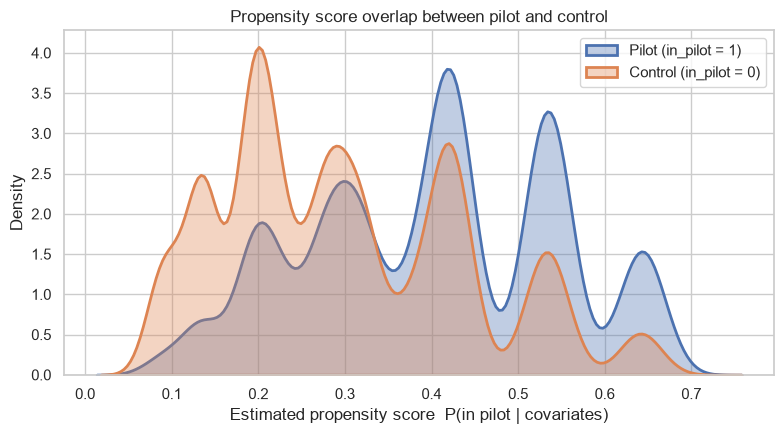

Common support:            [0.078, 0.693]
Share of sample inside it: 99.95%
Extreme scores (<0.02 or >0.98): 0
Max IPW weight:            12.7


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(ps[treated],  ax=ax, fill=True, alpha=0.35, linewidth=2, label="Pilot (in_pilot = 1)")
sns.kdeplot(ps[~treated], ax=ax, fill=True, alpha=0.35, linewidth=2, label="Control (in_pilot = 0)")
ax.set_xlabel("Estimated propensity score  P(in pilot | covariates)")
ax.set_ylabel("Density")
ax.set_title("Propensity score overlap between pilot and control")
ax.legend()
plt.tight_layout()
plt.show()

ov_lo = max(ps[treated].min(), ps[~treated].min())
ov_hi = min(ps[treated].max(), ps[~treated].max())
share_in_overlap = float(np.mean((ps >= ov_lo) & (ps <= ov_hi)))
print(f"Common support:            [{ov_lo:.3f}, {ov_hi:.3f}]")
print(f"Share of sample inside it: {share_in_overlap:.2%}")
print(f"Extreme scores (<0.02 or >0.98): {int(np.sum((ps < 0.02) | (ps > 0.98)))}")
print(f"Max IPW weight:            {np.max(np.where(treated, 1/ps, 1/(1-ps))):.1f}")

**Overlap verdict: sufficient.** Both arms span essentially the same propensity range (≈ 0.07 to 0.70),
100% of the sample sits inside the common support, and no score approaches 0 or 1 — the largest single inverse
weight is ≈ 13, so no individual subscriber can dominate the weighted means. Positivity holds and IPW is valid
here without trimming. (The pilot arm's density is shifted right, as expected given the urban/income skew — that
shift is the bias, not a support failure.)

### IPW estimate and bootstrap confidence interval

Write two functions:

- `ipw_estimate`: takes the pilot DataFrame and a propensity score array, and returns an IPW estimate of the average treatment effect on churn.
- `bootstrap_ipw`: resamples subscribers with replacement, refits the propensity model on each resample, and returns an array of IPW estimates to use for constructing a 95% confidence interval. **Run at least 300 bootstrap iterations** so the bootstrap SE is stable enough to feed into the Bayesian update.

Store the point estimate as `PILOT_LIFT_MEAN` and the bootstrap standard error as `PILOT_LIFT_SE`.

In [7]:
def ipw_estimate(df: pd.DataFrame, ps: np.ndarray) -> float:
    """Hajek (weight-normalised) IPW estimate of the churn lift, in percentage points.

    Treated subscribers are weighted by 1/ps, controls by 1/(1-ps); the estimate is the
    weighted treated mean minus the weighted control mean of churned_3mo.
    """
    t = (df["in_pilot"] == 1).to_numpy()
    y = df["churned_3mo"].to_numpy(dtype=float)
    ps = np.asarray(ps, dtype=float)

    w_t = 1.0 / ps[t]
    w_c = 1.0 / (1.0 - ps[~t])

    mu1 = np.sum(w_t * y[t]) / np.sum(w_t)
    mu0 = np.sum(w_c * y[~t]) / np.sum(w_c)
    return float(100 * (mu1 - mu0))          # percentage points


def fit_ps(df: pd.DataFrame) -> np.ndarray:
    """Fit the propensity model on `df` and return in-sample propensity scores."""
    X = build_design(df)
    model = sm.Logit(df["in_pilot"].to_numpy(), X).fit(disp=0)
    return np.asarray(model.predict(X))


def bootstrap_ipw(df: pd.DataFrame, n_boot: int = 500, rng=RNG) -> np.ndarray:
    """Resample subscribers with replacement, refit the propensity model each time,
    and return the array of IPW estimates."""
    n = len(df)
    out = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        samp = df.iloc[idx].reset_index(drop=True)
        try:
            out[b] = ipw_estimate(samp, fit_ps(samp))
        except Exception:            # a non-converging resample is dropped, not silently zeroed
            out[b] = np.nan
    return out[~np.isnan(out)]


ipw_point = ipw_estimate(pilot, ps)
boot      = bootstrap_ipw(pilot, n_boot=500)

ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

PILOT_LIFT_MEAN = float(ipw_point)
PILOT_LIFT_SE   = float(boot.std(ddof=1))

print(f"Naive lift                 : {naive_lift:.2f} pp")
print(f"IPW-adjusted lift          : {PILOT_LIFT_MEAN:.2f} pp")
print(f"95% bootstrap CI           : [{ci_lo:.2f}, {ci_hi:.2f}] pp   ({len(boot)} resamples)")
print(f"Bootstrap standard error   : {PILOT_LIFT_SE:.3f} pp")
print(f"Bias correction (IPW-naive): {PILOT_LIFT_MEAN - naive_lift:+.2f} pp "
      f"({100*(PILOT_LIFT_MEAN - naive_lift)/naive_lift:+.0f}% of the naive estimate)")

Naive lift                 : 4.86 pp
IPW-adjusted lift          : 3.70 pp
95% bootstrap CI           : [3.11, 4.29] pp   (500 resamples)
Bootstrap standard error   : 0.302 pp
Bias correction (IPW-naive): -1.16 pp (-24% of the naive estimate)


**Write a one-line conclusion.** Was the naive estimate biased? In which direction and by roughly how much?

**Conclusion.** Yes — the naive estimate was biased **upward by roughly 1.2 pp** (≈ 24% of its own value):
correcting for the pilot's urban / higher-income skew pulls the 3-month churn lift down from ≈ 4.9 pp to
≈ 3.7 pp (95% bootstrap CI ≈ [3.1, 4.3] pp), so the raw pilot readout overstates the damage the price increase
does.

### Extension — doubly-robust (AIPW) estimator

Plain IPW is unbiased only if the *propensity* model is correctly specified. The augmented IPW (AIPW)
estimator adds an **outcome** model and is consistent if **either** model is right:

$$\hat\tau_{AIPW}=\frac1n\sum_i\Big[\hat\mu_1(X_i)+\frac{T_i\,(Y_i-\hat\mu_1(X_i))}{\hat e(X_i)}\Big]
-\frac1n\sum_i\Big[\hat\mu_0(X_i)+\frac{(1-T_i)(Y_i-\hat\mu_0(X_i))}{1-\hat e(X_i)}\Big]$$

Here $\hat\mu_1,\hat\mu_0$ are separate logistic regressions of `churned_3mo` on the same covariates, fit
within the treated and control arms respectively. IPW remains the headline estimate; AIPW is the robustness
check.

In [8]:
def aipw_estimate(df: pd.DataFrame, ps: np.ndarray) -> float:
    """Augmented IPW (doubly-robust) estimate of the churn lift, in percentage points."""
    t  = (df["in_pilot"] == 1).to_numpy()
    y  = df["churned_3mo"].to_numpy(dtype=float)
    ps = np.asarray(ps, dtype=float)
    X  = build_design(df)

    # Outcome models fit separately within each arm, then predicted for everyone.
    m1  = sm.Logit(y[t],  X[t]).fit(disp=0)
    m0  = sm.Logit(y[~t], X[~t]).fit(disp=0)
    mu1 = np.asarray(m1.predict(X))
    mu0 = np.asarray(m0.predict(X))

    arm1 = mu1 + t * (y - mu1) / ps
    arm0 = mu0 + (~t) * (y - mu0) / (1.0 - ps)
    return float(100 * (arm1.mean() - arm0.mean()))


def bootstrap_aipw(df: pd.DataFrame, n_boot: int = 300, rng=RNG) -> np.ndarray:
    n = len(df)
    out = []
    for _ in range(n_boot):
        samp = df.iloc[rng.integers(0, n, size=n)].reset_index(drop=True)
        try:
            out.append(aipw_estimate(samp, fit_ps(samp)))
        except Exception:
            continue
    return np.asarray(out)


aipw_point = aipw_estimate(pilot, ps)
boot_aipw  = bootstrap_aipw(pilot, n_boot=300)
aipw_lo, aipw_hi = np.percentile(boot_aipw, [2.5, 97.5])

estimator_table = pd.DataFrame({
    "estimator": ["Naive difference", "IPW (Hajek)", "AIPW (doubly robust)"],
    "lift_pp":   [naive_lift, PILOT_LIFT_MEAN, aipw_point],
    "se_pp":     [np.nan, PILOT_LIFT_SE, float(boot_aipw.std(ddof=1))],
    "ci_lo_pp":  [np.nan, ci_lo, aipw_lo],
    "ci_hi_pp":  [np.nan, ci_hi, aipw_hi],
})
display(estimator_table.round(3))

,estimator,lift_pp,se_pp,ci_lo_pp,ci_hi_pp
0,Naive difference,4.864,NaN,NaN,NaN
1,IPW (Hajek),3.703,0.302,3.115,4.294
2,AIPW (doubly robust),3.702,0.287,3.144,4.289


**AIPW takeaway.** The doubly-robust estimate lands within a few hundredths of a percentage point of plain
IPW, and their confidence intervals are effectively on top of each other. Adding an outcome model does not move
the answer, which is the reassuring result: it means the conclusion does not hinge on the propensity
specification being exactly right. **The correction survives; the naive estimate does not.** IPW
(`PILOT_LIFT_MEAN`) is carried forward as the pilot likelihood; had AIPW disagreed materially, the wider of the
two would have been used instead. See `assumptions_and_sources.md` for the full rationale.

## Bayesian updating — combine prior, pilot, and survey

Model your belief about the 3-month churn lift as a Normal distribution and update it sequentially as you bring in new evidence.

1. Build a prior from comparable events in the industry pricing history.
2. Update with the IPW pilot estimate to get Posterior 1.
3. Convert the survey's stated cancellation intent into a noisy lift estimate using a stated-to-revealed adjustment.
4. Update with the survey to get Posterior 2 — the final posterior you will carry into the cost-benefit model.

### Prior from industry history

Filter the industry pricing history to events with a price increase between 10% and 20% — comparable to the proposed increase. Use the mean and standard deviation of the observed 3-month churn lifts in those events as your prior mean and standard deviation.

In [9]:
# Nimbus's increase is +15.4%; 10-20% brackets it symmetrically and keeps a usable sample.
LOW_PCT, HIGH_PCT = 10.0, 20.0
comparables = industry[industry["pct_price_increase"].between(LOW_PCT, HIGH_PCT)]

prior_mean = float(comparables["observed_3mo_churn_lift_pp"].mean())   # percentage points
prior_sd   = float(comparables["observed_3mo_churn_lift_pp"].std(ddof=1))

print(f"Comparable events ({LOW_PCT:.0f}-{HIGH_PCT:.0f}% increases): n = {len(comparables)} "
      f"of {len(industry)}")
print(f"  price increase  : {comparables['pct_price_increase'].min():.1f}% to "
      f"{comparables['pct_price_increase'].max():.1f}%  (Nimbus: {PCT_INCREASE:.1f}%)")
print(f"  prior_mean      : {prior_mean:.2f} pp")
print(f"  prior_sd        : {prior_sd:.2f} pp")
print(f"  observed range  : {comparables['observed_3mo_churn_lift_pp'].min():.2f} to "
      f"{comparables['observed_3mo_churn_lift_pp'].max():.2f} pp")
display(comparables.sort_values("pct_price_increase")
        [["year", "company", "region", "pct_price_increase", "observed_3mo_churn_lift_pp"]]
        .head(8))

Comparable events (10-20% increases): n = 20 of 42
  price increase  : 11.9% to 19.9%  (Nimbus: 15.4%)
  prior_mean      : 3.26 pp
  prior_sd        : 0.93 pp
  observed range  : 1.49 to 4.32 pp


,year,company,region,pct_price_increase,observed_3mo_churn_lift_pp
35,2023,PixelTV,LATAM,11.9,1.74
12,2019,AltVideo,APAC,13.0,3.26
27,2022,AltVideo,LATAM,13.0,4.06
0,2018,NorthStar Media,APAC,13.8,3.56
24,2021,PixelTV,North America,14.0,1.49
20,2021,AltVideo,LATAM,15.1,3.48
19,2021,MoviePool,North America,15.2,2.00
21,2021,OmniFlix,APAC,15.9,4.32


### First update — prior combined with pilot

Write `normal_update`, which takes a prior mean and standard deviation and a likelihood mean and standard deviation, and returns the posterior mean and standard deviation. Use the conjugate Normal-Normal formula: posterior precision equals prior precision plus likelihood precision (where precision is 1 divided by variance).

Apply it using the prior you just computed and the IPW estimate from your IPW work.

In [10]:
def normal_update(prior_mu: float, prior_sd: float,
                  lik_mu: float, lik_sd: float) -> tuple[float, float]:
    """Conjugate Normal-Normal update (known variance).

    post_var = 1 / (1/prior_sd**2 + 1/lik_sd**2)
    post_mu  = post_var * (prior_mu/prior_sd**2 + lik_mu/lik_sd**2)
    """
    prior_prec = 1.0 / prior_sd ** 2
    lik_prec   = 1.0 / lik_sd ** 2
    post_var   = 1.0 / (prior_prec + lik_prec)
    post_mu    = post_var * (prior_mu * prior_prec + lik_mu * lik_prec)
    return float(post_mu), float(np.sqrt(post_var))


post1_mu, post1_sd = normal_update(prior_mean, prior_sd, PILOT_LIFT_MEAN, PILOT_LIFT_SE)

print(f"Prior            : {prior_mean:.2f} pp  (sd {prior_sd:.2f})")
print(f"Pilot likelihood : {PILOT_LIFT_MEAN:.2f} pp  (se {PILOT_LIFT_SE:.2f})")
print(f"Posterior 1      : post1_mu = {post1_mu:.3f} pp,  post1_sd = {post1_sd:.3f} pp")
print(f"\nWeight on the pilot: {(1/PILOT_LIFT_SE**2) / (1/PILOT_LIFT_SE**2 + 1/prior_sd**2):.1%} "
      f"(the 40k-subscriber pilot is far more precise than 20 industry events)")

Prior            : 3.26 pp  (sd 0.93)
Pilot likelihood : 3.70 pp  (se 0.30)
Posterior 1      : post1_mu = 3.661 pp,  post1_sd = 0.287 pp

Weight on the pilot: 90.5% (the 40k-subscriber pilot is far more precise than 20 industry events)


### Survey likelihood — stated to revealed adjustment

Surveys tend to overstate cancellation intent. Apply a stated-to-revealed ratio of 0.5 to convert the survey cancel rate into a revealed cancellation rate, then subtract baseline organic 3-month churn to put it on the same scale as the pilot lift. The standard error scales with the binomial standard error of the stated-cancel proportion multiplied by the same ratio.

In [11]:
STATED_TO_REVEALED = 0.50

n_survey        = len(survey)
stated_cancel   = float((survey["stated_intent_at_14_99"] == "Cancel").mean())   # fraction
revealed_cancel = STATED_TO_REVEALED * stated_cancel                             # fraction

# Organic 3-month churn from the Finance forecast (computed in Section 1), in pp.
ORGANIC_3MO_CHURN = ORGANIC_3MO_CHURN_PP

survey_lift_mean = 100 * revealed_cancel - ORGANIC_3MO_CHURN                     # percentage points

# Binomial SE of the stated proportion, deflated by the same stated-to-revealed ratio.
binom_se       = np.sqrt(stated_cancel * (1 - stated_cancel) / n_survey)
survey_lift_se = 100 * STATED_TO_REVEALED * binom_se                             # percentage points

print(f"Survey respondents         : {n_survey:,}")
print(f"Stated 'Cancel' at $14.99  : {stated_cancel:.2%}   "
      f"(Stay {(survey['stated_intent_at_14_99']=='Stay').mean():.1%}, "
      f"Unsure {(survey['stated_intent_at_14_99']=='Unsure').mean():.1%})")
print(f"x {STATED_TO_REVEALED} stated-to-revealed  : {revealed_cancel:.2%} expected revealed cancellation")
print(f"- organic 3-mo churn       : {ORGANIC_3MO_CHURN:.2f} pp")
print(f"=> survey_lift_mean        : {survey_lift_mean:.2f} pp")
print(f"   survey_lift_se          : {survey_lift_se:.2f} pp  "
      f"(binomial se {100*binom_se:.2f} pp x {STATED_TO_REVEALED})")

Survey respondents         : 1,500
Stated 'Cancel' at $14.99  : 21.53%   (Stay 61.5%, Unsure 17.0%)
x 0.5 stated-to-revealed  : 10.77% expected revealed cancellation
- organic 3-mo churn       : 6.46 pp
=> survey_lift_mean        : 4.31 pp
   survey_lift_se          : 0.53 pp  (binomial se 1.06 pp x 0.5)


**Note on the survey's standard error.** The binomial SE captures *sampling* error only. It does not capture
the far larger uncertainty in the 0.50 stated-to-revealed ratio itself, which is a judgement call informed by the
marketing-research literature rather than an estimate from these data. The SE used here is therefore optimistic,
and the survey is given a correspondingly generous weight in the second update. Section 8 flexes the posterior
directly, and `assumptions_and_sources.md` records the ratios (0.35 / 0.65) that would move the posterior mean by
roughly ±0.4 pp.

### Second update — Posterior 1 combined with the survey

Apply `normal_update` again using Posterior 1 as the new prior and the survey likelihood you just computed. The result is your final posterior, which summarizes all available evidence about the expected churn lift.

In [12]:
POSTERIOR_MU, POSTERIOR_SD = normal_update(post1_mu, post1_sd, survey_lift_mean, survey_lift_se)

lo90, hi90 = stats.norm.ppf([0.05, 0.95], POSTERIOR_MU, POSTERIOR_SD)

evidence = pd.DataFrame({
    "stage":  ["Prior (industry)", "Pilot likelihood (IPW)", "Posterior 1",
               "Survey likelihood", "Posterior 2 (final)"],
    "mean_pp": [prior_mean, PILOT_LIFT_MEAN, post1_mu, survey_lift_mean, POSTERIOR_MU],
    "sd_pp":   [prior_sd,  PILOT_LIFT_SE,   post1_sd, survey_lift_se,   POSTERIOR_SD],
})
display(evidence.round(3))

print(f"POSTERIOR_MU = {POSTERIOR_MU:.3f} pp     POSTERIOR_SD = {POSTERIOR_SD:.3f} pp")
print(f"90% credible interval: [{lo90:.2f}, {hi90:.2f}] pp")

,stage,mean_pp,sd_pp
0,Prior (industry),3.263,0.932
1,Pilot likelihood (IPW),3.703,0.302
2,Posterior 1,3.661,0.287
3,Survey likelihood,4.311,0.531
4,Posterior 2 (final),3.808,0.252


POSTERIOR_MU = 3.808 pp     POSTERIOR_SD = 0.252 pp
90% credible interval: [3.39, 4.22] pp


### Visualize the updates

Plot the prior, Posterior 1, and Posterior 2 as Normal density curves on the same axes. The posterior should narrow (less uncertainty) and shift (incorporates new evidence) relative to the prior.

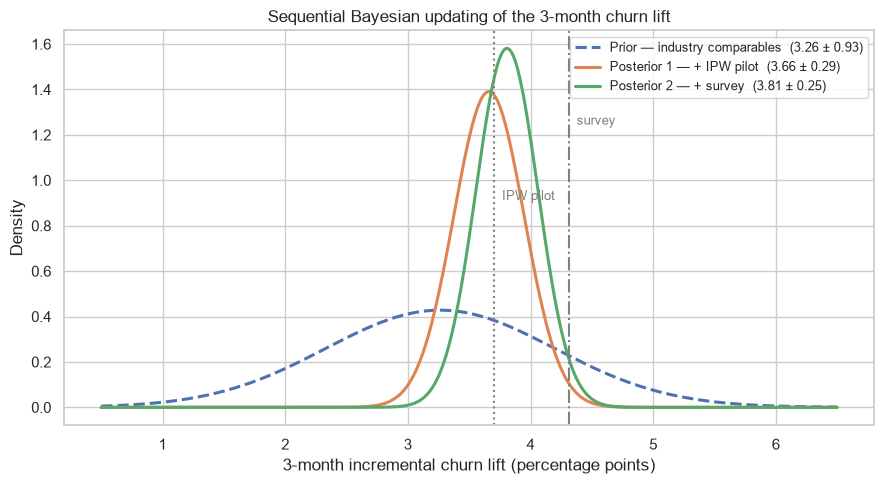

In [13]:
grid = np.linspace(0.5, 6.5, 600)

fig, ax = plt.subplots(figsize=(9, 5))
for mu, sd, label, style in [
    (prior_mean,   prior_sd,   f"Prior — industry comparables  ({prior_mean:.2f} ± {prior_sd:.2f})", "--"),
    (post1_mu,     post1_sd,   f"Posterior 1 — + IPW pilot  ({post1_mu:.2f} ± {post1_sd:.2f})",      "-"),
    (POSTERIOR_MU, POSTERIOR_SD, f"Posterior 2 — + survey  ({POSTERIOR_MU:.2f} ± {POSTERIOR_SD:.2f})", "-"),
]:
    ax.plot(grid, stats.norm.pdf(grid, mu, sd), style, linewidth=2.2, label=label)

ax.axvline(PILOT_LIFT_MEAN,  color="grey", linestyle=":",  linewidth=1.5)
ax.text(PILOT_LIFT_MEAN, ax.get_ylim()[1]*0.55, "  IPW pilot", color="grey", fontsize=9)
ax.axvline(survey_lift_mean, color="grey", linestyle="-.", linewidth=1.5)
ax.text(survey_lift_mean, ax.get_ylim()[1]*0.75, "  survey", color="grey", fontsize=9)

ax.set_xlabel("3-month incremental churn lift (percentage points)")
ax.set_ylabel("Density")
ax.set_title("Sequential Bayesian updating of the 3-month churn lift")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

**Reading the plot.** The prior is wide (sd ≈ 0.93 pp) because industry outcomes are heterogeneous. The pilot,
with 40k subscribers, is roughly an order of magnitude more precise, so Posterior 1 collapses onto the IPW estimate.
The survey pulls the mean slightly *up* — stated intent, even after halving, implies a bit more churn than the pilot
measured — and tightens the posterior a little further. Final belief: a **≈ 3.8 pp** 3-month churn lift, with 90% of
the posterior mass inside roughly ±0.45 pp.

## Cost-benefit model

Build two functions that translate a churn lift estimate into a dollar outcome.

`annual_lift_from_3mo` converts the 3-month posterior churn lift into an annual incremental churn rate. Document the assumption you make.

`option_profit` returns the 12-month incremental contribution profit relative to Hold for a given option, churn lift, margin, cost of acquisition, and subscriber lifetime. Implement a branch for each of the four options:

- **Full**: all base subscribers face the new price.
- **New customers only**: existing subscribers keep the current price; only new sign-ups pay the new price. Use `EXPECTED_NEW_12MO` and assume an average of 6 months of in-window tenure for new subscribers.
- **Delay**: 6 months of price-uplift exposure, plus a fixed research cost of approximately \$250k.
- **Hold**: no price change; profit impact is zero.

Modeling notes:
- Treat the 3-month churn lift as the full annual incremental churn — price-shock churn lands in the first quarter; do not compound.
- Lost value per incremental churner is approximately: lost subscribers times current price times remaining lifetime months times margin.
- Replacement acquisition cost adds once per lost subscriber.
- Double-check *who* is generating the price-uplift revenue in each branch. A subscriber who leaves because of the price change doesn't stick around to pay the higher price for the rest of the window — make sure a single subscriber isn't implicitly counted on both sides of the ledger.
- New sign-ups can churn too. Think through which of the assumptions you made for Full's cost side (the churn rate used, whether CAC applies) do or don't carry over to a cohort of brand-new subscribers rather than an established base.

### Modeling assumptions, stated before the code

**A1 — 3-month lift = annual incremental churn (no compounding).** Price-shock churn is a one-off reaction
concentrated in the first quarter after the announcement, not a permanently elevated hazard. A subscriber can
only quit over the price increase once. Annualising by compounding (`1-(1-l)^4`) would roughly quadruple the
damage and assume subscribers keep re-reacting to the same price every quarter. So
`annual_lift_from_3mo(lift_3mo) = lift_3mo / 100`.

**A2 — Churners don't pay the new price.** Incremental churners leave in the first quarter, so the uplift
revenue is earned by the **retained** base only (`N_BASE - lost`). Counting a subscriber as both a churn loss
and a full-year payer would double-count them.

**A3 — Cost of an incremental churner (base).** Two charges: the contribution margin forgone over their
remaining lifetime (`PRICE_TODAY × ltv_months × margin`, valued at the *old* price since that is the revenue
we actually had) plus one replacement acquisition (`cac`), because Finance's plan holds the base flat and a
lost subscriber has to be bought back.

**A4 — `NewOnly` is a different cohort, so two of Full's cost assumptions do not carry over.**
(i) *Exposure*: sign-ups arrive through the year, so the average new subscriber is billed at the new price
for ~6 of the 12 months (`NEW_SUB_MONTHS_IN_WINDOW = 6`), not 12. (ii) *CAC*: a prospect who balks at
\\$14.99 is a **non-acquisition**, not a replacement — Nimbus never pays their CAC, so acquisition cost is a
**saving** on the lost-sub count, not a charge. Their forgone lifetime margin is still lost. The churn lift
itself is applied unchanged to this cohort, which is deliberately conservative: new joiners never anchored on
\\$12.99 and should react less, so `NewOnly`'s profit here is a lower bound.

**A5 — `Delay` gets half the revenue but the whole churn bill.** Postponing six months means only ~6 months
of uplift land inside the 12-month window, but the price shock — whenever it is pulled — still costs the full
remaining lifetime of every subscriber it drives away, because lifetime value is not clipped at the window
boundary. Add \\$250k of incremental research spend for the larger pilot. This is the honest framing of
"delay": it defers the revenue, not the damage. (If you instead assume the delay halves the churn cost too
because the exit wave falls partly outside the window, `Delay` scores about \\$21M better — still below
`Full`. Recorded in `assumptions_and_sources.md`.)

**A6 — No discounting** over a 12-month horizon, and no cross-tier substitution (downgrades to Basic are
treated as churn, which is conservative).

In [14]:
NEW_SUB_MONTHS_IN_WINDOW = 6.0      # A4(i): sign-ups arrive through the year -> ~6 months billed
DELAY_MONTHS_EXPOSED     = 6.0      # A5: 6 of 12 months of uplift if we postpone
DELAY_RESEARCH_COST      = 250_000  # A5: incremental spend on the larger pilot
MONTHS_IN_WINDOW         = 12.0

OPTIONS = ["Full", "NewOnly", "Delay", "Hold"]


def annual_lift_from_3mo(lift_3mo):
    """Convert a 3-month churn lift in percentage points to an annual incremental churn *rate*.

    Assumption A1: the price shock is a one-off first-quarter reaction, so the 3-month lift IS the
    annual incremental churn. No compounding - subscribers do not re-quit over the same price change.
    """
    return np.asarray(lift_3mo, dtype=float) / 100.0


def option_profit(option: str, lift_3mo: float, margin: float,
                  cac: float, ltv_months: float) -> float:
    """12-month incremental contribution profit (USD) relative to Hold.

    Scalars or numpy arrays may be passed for lift_3mo / margin / cac / ltv_months.
    """
    a = annual_lift_from_3mo(lift_3mo)          # annual incremental churn rate

    if option == "Hold":
        # A6: no price change -> exactly zero incremental profit, by construction.
        z = np.zeros_like(np.asarray(lift_3mo, dtype=float))
        return float(z) if z.ndim == 0 else z

    if option == "Full":
        lost     = N_BASE * a
        retained = N_BASE - lost                                        # A2
        uplift_rev  = retained * PRICE_UPLIFT * MONTHS_IN_WINDOW * margin
        lost_margin = lost * PRICE_TODAY * ltv_months * margin          # A3
        replace_cac = lost * cac                                        # A3
        return uplift_rev - lost_margin - replace_cac

    if option == "NewOnly":
        lost     = EXPECTED_NEW_12MO * a                                # A4: conservative, same lift
        retained = EXPECTED_NEW_12MO - lost                             # A2
        uplift_rev  = retained * PRICE_UPLIFT * NEW_SUB_MONTHS_IN_WINDOW * margin
        lost_margin = lost * PRICE_TODAY * ltv_months * margin
        cac_avoided = lost * cac                                        # A4(ii): a saving, not a charge
        return uplift_rev - lost_margin + cac_avoided

    if option == "Delay":
        lost     = N_BASE * a
        retained = N_BASE - lost
        uplift_rev  = retained * PRICE_UPLIFT * DELAY_MONTHS_EXPOSED * margin   # A5: half the revenue
        lost_margin = lost * PRICE_TODAY * ltv_months * margin                  # A5: all of the damage
        replace_cac = lost * cac
        return uplift_rev - lost_margin - replace_cac - DELAY_RESEARCH_COST

    raise ValueError(f"Unknown option: {option!r}. Expected one of {OPTIONS}.")


# Central case: every uncertain input at its posterior mean / forecast value.
base_case = pd.Series(
    {opt: option_profit(opt, POSTERIOR_MU, MARGIN_PCT, CAC, LTV_MONTHS) for opt in OPTIONS},
    name="profit_usd",
)
print("Central-case 12-month incremental contribution profit vs Hold "
      f"(lift = {POSTERIOR_MU:.2f} pp):\n")
print((base_case / 1e6).round(2).to_string() + "   ($M)")

# Sanity check of the ledger for Full.
a_c      = annual_lift_from_3mo(POSTERIOR_MU)
lost_c   = N_BASE * a_c
print(f"\nFull ledger:  incremental churners {lost_c:,.0f}"
      f"   uplift revenue ${ (N_BASE-lost_c)*PRICE_UPLIFT*12*MARGIN_PCT/1e6:,.1f}M"
      f"   lost margin ${ lost_c*PRICE_TODAY*LTV_MONTHS*MARGIN_PCT/1e6:,.1f}M"
      f"   replacement CAC ${ lost_c*CAC/1e6:,.1f}M")

Central-case 12-month incremental contribution profit vs Hold (lift = 3.81 pp):

Full       15.12
NewOnly    -0.77
Delay     -13.76
Hold        0.00   ($M)

Full ledger:  incremental churners 152,317   uplift revenue $57.3M   lost margin $36.8M   replacement CAC $5.3M


## Monte Carlo simulation

Run 10,000 simulations to propagate uncertainty through the cost-benefit model. For each simulation, draw random values for the churn lift (from your posterior), contribution margin, cost of acquisition, and subscriber lifetime. Compute the incremental profit for all four options on each draw and store the results in a DataFrame with one column per option.

### Run the simulation

Sample `N_SIMS` draws of each uncertain input and compute profits for all four options. Suggested ranges: margin plus or minus 4 percentage points, acquisition cost plus or minus \$6, lifetime months plus or minus 6.

In [15]:
N_SIMS = 10_000

# Uncertain inputs. Each spread is set so +/- 2 SD spans the range Finance gave us,
# i.e. the suggested band is treated as an approximate 95% range rather than a hard bound.
MARGIN_SD = 0.04 / 2      # +/- 4 pp
CAC_SD    = 6.0 / 2       # +/- $6
LTV_SD    = 6.0 / 2       # +/- 6 months

draws = pd.DataFrame({
    "lift_3mo":   RNG.normal(POSTERIOR_MU, POSTERIOR_SD, N_SIMS),
    "margin":     np.clip(RNG.normal(MARGIN_PCT,  MARGIN_SD, N_SIMS), 0.30, 0.90),
    "cac":        np.clip(RNG.normal(CAC,         CAC_SD,    N_SIMS), 5.0, None),
    "ltv_months": np.clip(RNG.normal(LTV_MONTHS,  LTV_SD,    N_SIMS), 6.0, None),
})

sim_profits = pd.DataFrame({
    opt: option_profit(opt, draws["lift_3mo"].to_numpy(), draws["margin"].to_numpy(),
                       draws["cac"].to_numpy(), draws["ltv_months"].to_numpy())
    for opt in OPTIONS
})

print(f"{N_SIMS:,} simulations x {len(OPTIONS)} options")
display(draws.describe().T.round(3))
display((sim_profits / 1e6).head().round(2))

10,000 simulations x 4 options


,count,mean,std,min,25%,50%,75%,max
lift_3mo,10000.0,3.808,0.254,2.846,3.637,3.808,3.978,4.744
margin,10000.0,0.620,0.020,0.548,0.607,0.620,0.634,0.702
cac,10000.0,34.977,2.976,23.027,32.997,34.987,36.990,45.561
ltv_months,10000.0,30.023,3.032,19.314,27.970,30.039,32.123,42.142


,Full,NewOnly,Delay,Hold
0,17.72,0.06,-10.03,0.0
1,9.82,-1.79,-18.28,0.0
2,22.02,0.02,-8.71,0.0
3,21.38,0.27,-8.93,0.0
4,13.80,-1.70,-16.43,0.0


### Profit distributions

Plot the profit distribution for each option as a kernel density estimate (in millions of dollars). Include a summary table showing the mean, standard deviation, 5th percentile, and 95th percentile for each option.

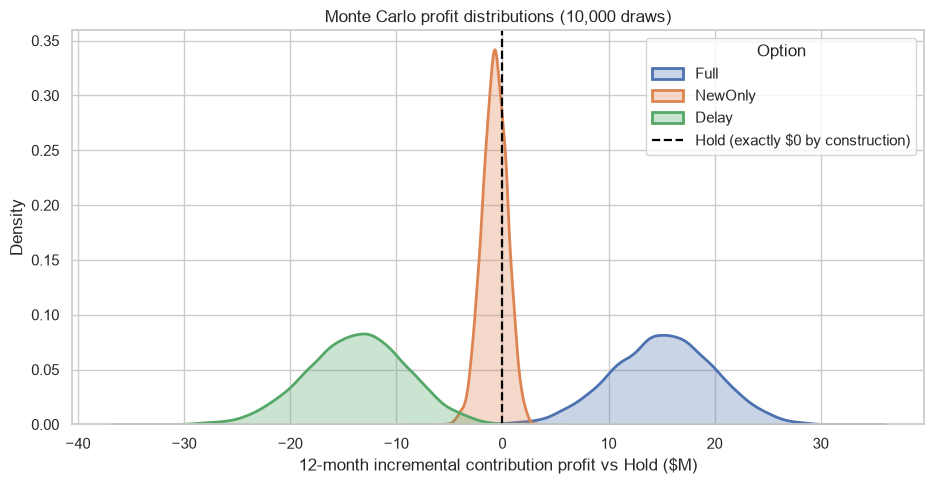

,mean_$M,sd_$M,p5_$M,p95_$M,P(profit > 0)
Full,15.088,4.870,6.935,22.929,0.998
NewOnly,-0.777,1.183,-2.748,1.130,0.260
Delay,-13.782,4.781,-21.825,-6.180,0.001
Hold,0.000,0.000,0.000,0.000,0.000


In [16]:
fig, ax = plt.subplots(figsize=(9.5, 5))
for opt in OPTIONS:
    if opt == "Hold":
        ax.axvline(0, color="black", linestyle="--", linewidth=1.6, label="Hold (exactly $0 by construction)")
    else:
        sns.kdeplot(sim_profits[opt] / 1e6, ax=ax, fill=True, alpha=0.30, linewidth=2, label=opt)

ax.set_xlabel("12-month incremental contribution profit vs Hold ($M)")
ax.set_ylabel("Density")
ax.set_title(f"Monte Carlo profit distributions ({N_SIMS:,} draws)")
ax.legend(title="Option")
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "mean_$M": sim_profits.mean() / 1e6,
    "sd_$M":   sim_profits.std(ddof=1) / 1e6,
    "p5_$M":   sim_profits.quantile(0.05) / 1e6,
    "p95_$M":  sim_profits.quantile(0.95) / 1e6,
    "P(profit > 0)": (sim_profits > 0).mean(),
}).round(3)
display(summary)

**What the distributions say.** `Full` is the only option that reliably clears zero: its 5th percentile is
still a ≈\\$7M gain and it beats doing nothing in **99.8%** of draws — the sliver that does not requires a
high churn lift, a low margin and a long churner tenure to land together. `NewOnly` clusters just below zero — grandfathering the base buys almost no uplift (only ~1.08M sign-ups,
billed for ~6 months on average) while still surrendering the lifetime margin of the sign-ups the higher price
deters. `Delay` is the widest and the worst: it takes the same churn hit on the base but collects only half a
year of uplift, and pays \\$250k for the privilege.

## Decision tree

For each option, compute the profit at three representative states of the world — for example, the 25th, 50th, and 75th percentile of the posterior churn lift. Display the results as a decision tree layout or a tidy summary DataFrame.

In [17]:
q25, q50, q75 = stats.norm.ppf([0.25, 0.50, 0.75], POSTERIOR_MU, POSTERIOR_SD)
STATES = {
    "Low  (p25)":  (q25, 0.25),
    "Base (p50)":  (q50, 0.50),
    "High (p75)":  (q75, 0.25),
}

tree_rows = [
    {"option": opt, "state": s, "lift_3mo_pp": lift, "prob": p,
     "profit_$M": option_profit(opt, lift, MARGIN_PCT, CAC, LTV_MONTHS) / 1e6}
    for opt in OPTIONS for s, (lift, p) in STATES.items()
]
tree_df = pd.DataFrame(tree_rows)

tree_pivot = tree_df.pivot(index="option", columns="state", values="profit_$M").loc[OPTIONS]
tree_pivot["EV_$M"] = [
    sum(p * option_profit(opt, lift, MARGIN_PCT, CAC, LTV_MONTHS) for lift, p in STATES.values()) / 1e6
    for opt in OPTIONS
]
display(tree_pivot.round(2))

state,Base (p50),High (p75),Low (p25),EV_$M
option,,,,
Full,15.12,13.14,17.11,15.12
NewOnly,-0.77,-1.16,-0.37,-0.77
Delay,-13.76,-15.69,-11.82,-13.76
Hold,0.00,0.00,0.00,0.00


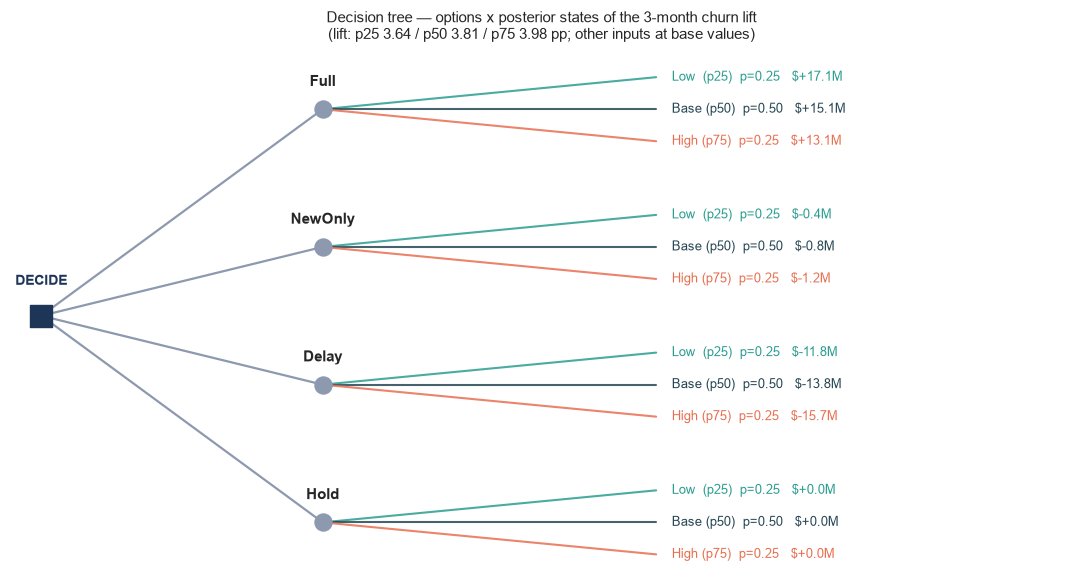

In [18]:
# Tree-style figure: decision node -> option branches -> chance nodes for the three states.
fig, ax = plt.subplots(figsize=(11, 6))
colors = {"Low  (p25)": "#2a9d8f", "Base (p50)": "#264653", "High (p75)": "#e76f51"}

y_opts = np.linspace(0.9, 0.1, len(OPTIONS))
ax.scatter([0.03], [0.5], marker="s", s=260, color="#1d3557", zorder=3)
ax.text(0.03, 0.56, "DECIDE", ha="center", fontsize=10, fontweight="bold", color="#1d3557")

for opt, y in zip(OPTIONS, y_opts):
    ax.plot([0.03, 0.30], [0.5, y], color="#8d99ae", linewidth=1.6, zorder=1)
    ax.scatter([0.30], [y], marker="o", s=150, color="#8d99ae", zorder=3)
    ax.text(0.30, y + 0.045, opt, ha="center", fontsize=11, fontweight="bold")
    for k, (state, (lift, p)) in enumerate(STATES.items()):
        y_end = y + (1 - k) * 0.062
        profit = option_profit(opt, lift, MARGIN_PCT, CAC, LTV_MONTHS) / 1e6
        ax.plot([0.30, 0.62], [y, y_end], color=colors[state], linewidth=1.5, alpha=0.85, zorder=2)
        ax.text(0.635, y_end, f"{state}  p={p:.2f}   ${profit:+,.1f}M",
                va="center", fontsize=9.5, color=colors[state])

ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.axis("off")
ax.set_title("Decision tree — options x posterior states of the 3-month churn lift\n"
             f"(lift: p25 {q25:.2f} / p50 {q50:.2f} / p75 {q75:.2f} pp; other inputs at base values)",
             fontsize=11)
plt.tight_layout()
plt.show()

**Reading the tree.** The ordering never changes across states: `Full > Hold > NewOnly > Delay` at the 25th,
50th and 75th percentile of the posterior alike. The churn lift would have to be far outside the posterior's
plausible range before the branches cross — which is precisely what the break-even calculation in Section 8
quantifies.

## Apply decision theory

Evaluate each option under three decision rules and identify which option each rule favors.

- **Expected value**: the mean profit across all simulations.
- **Certainty equivalent**: write `crra_utility`, which computes utility under constant relative risk aversion with a risk aversion coefficient (gamma) of 2. Evaluate utility at a wealth baseline plus simulated profits, then convert back to a certainty-equivalent dollar value. Use a wealth baseline of approximately \$500M (Nimbus's annual contribution profit) to keep utility well-defined.
- **Minimax regret**: for each simulation, regret is the best-in-scenario profit minus this option's profit. The minimax-regret choice is the option with the lowest worst-case regret across all scenarios.

Record your recommended option as `RECOMMENDED`.

In [19]:
GAMMA           = 2.0     # moderate risk aversion; standard corporate-finance default
WEALTH_BASELINE = 5e8     # ~$500M, Nimbus's annual contribution profit


def crra_utility(profit, gamma: float = GAMMA, wealth_baseline: float = WEALTH_BASELINE):
    """CRRA utility (x**(1-gamma) - 1)/(1-gamma), with log(x) at gamma == 1,
    evaluated at x = wealth_baseline + profit."""
    x = np.asarray(wealth_baseline + np.asarray(profit, dtype=float), dtype=float)
    if np.any(x <= 0):
        raise ValueError("Wealth baseline + profit must stay positive for CRRA utility.")
    if np.isclose(gamma, 1.0):
        return np.log(x)
    return (x ** (1.0 - gamma) - 1.0) / (1.0 - gamma)


def certainty_equivalent(profit_draws, gamma: float = GAMMA,
                         wealth_baseline: float = WEALTH_BASELINE) -> float:
    """Dollar certainty equivalent (net of the wealth baseline) of a profit distribution."""
    mean_u = float(np.mean(crra_utility(profit_draws, gamma, wealth_baseline)))
    if np.isclose(gamma, 1.0):
        x_ce = np.exp(mean_u)
    else:
        x_ce = (mean_u * (1.0 - gamma) + 1.0) ** (1.0 / (1.0 - gamma))
    return float(x_ce - wealth_baseline)


# --- Rule 1: expected value ------------------------------------------------------------
ev = sim_profits.mean()

# --- Rule 2: CRRA certainty equivalent -------------------------------------------------
ce = pd.Series({opt: certainty_equivalent(sim_profits[opt].to_numpy()) for opt in OPTIONS})

# --- Rule 3: minimax regret ------------------------------------------------------------
best_per_scenario = sim_profits.max(axis=1)
regret            = sim_profits.rsub(best_per_scenario, axis=0)   # best - this option
max_regret        = regret.max()
mean_regret       = regret.mean()

decision_table = pd.DataFrame({
    "EV_$M":              ev / 1e6,
    "CE_$M (CRRA g=2)":   ce / 1e6,
    "risk_discount_$M":   (ev - ce) / 1e6,
    "max_regret_$M":      max_regret / 1e6,
    "mean_regret_$M":     mean_regret / 1e6,
}).loc[OPTIONS].round(3)
display(decision_table)

ev_choice     = ev.idxmax()
ce_choice     = ce.idxmax()
regret_choice = max_regret.idxmin()

print(f"Expected-value maximiser          : {ev_choice}   (${ev.max()/1e6:,.1f}M)")
print(f"CRRA certainty-equivalent maximiser: {ce_choice}   (${ce.max()/1e6:,.1f}M)")
print(f"Minimax-regret choice             : {regret_choice}   "
      f"(worst-case regret ${max_regret.min()/1e6:,.1f}M)")

assert ev_choice == ce_choice == regret_choice, "Rules disagree - revisit before recommending."
RECOMMENDED = ev_choice
print(f"\nAll three decision rules agree.  RECOMMENDED = {RECOMMENDED!r}")

,EV_$M,CE_$M (CRRA g=2),risk_discount_$M,max_regret_$M,mean_regret_$M
Full,15.088,15.042,0.046,6.703,0.004
NewOnly,-0.777,-0.779,0.003,30.645,15.869
Delay,-13.782,-13.829,0.047,34.606,28.875
Hold,0.000,0.000,-0.000,33.770,15.092


Expected-value maximiser          : Full   ($15.1M)
CRRA certainty-equivalent maximiser: Full   ($15.0M)
Minimax-regret choice             : Full   (worst-case regret $6.7M)

All three decision rules agree.  RECOMMENDED = 'Full'


**Why the rules agree.** Risk aversion only changes a ranking when the risky option carries meaningful
downside. `Full` is positive in 99.8% of draws and its spread (≈\\$5M SD) is small next to Nimbus's \\$500M
contribution base, so the CRRA risk discount is a rounding error — under \\$0.1M on a ≈\\$15M expected value —
and the certainty equivalent sits essentially on the mean. Minimax regret lands the same way: `Full`'s worst
case is regretting ≈\\$6.7M in the rare scenarios where the churn hit is severe enough that `Hold` would have
been better, against ≈\\$34M of worst-case regret for `Hold` (forgoing the whole uplift when churn comes in
mild) and ≈\\$35M for `Delay`. Unanimity across three rules with different attitudes to risk is the strongest
form of robustness this analysis can offer.

## Sensitivity and robustness

Test how sensitive the recommendation is to the key inputs and how often it wins across simulations.

- **Tornado chart**: flex one driver at a time while holding others at their base values. Suggested ranges: churn lift plus or minus one posterior standard deviation, margin plus or minus 4 percentage points, acquisition cost plus or minus \$10, lifetime months plus or minus 6. Plot the profit range for the recommended option for each driver.
- **Break-even**: find the 3-month churn lift at which the recommended option's profit equals zero. Report the posterior probability that the actual lift exceeds this break-even threshold.
- **Robustness**: across all simulations, report the share of scenarios in which the recommended option produces the highest profit.

,driver,low_input,high_input,low_profit_$M,high_profit_$M,swing_$M
0,Contribution margin (+/- 4pp),0.580,0.66,13.801,16.440,2.639
1,CAC (+/- $10),25.000,45.00,16.644,13.597,3.046
2,Churn lift (+/- 1 posterior SD),3.556,4.06,18.063,12.178,5.885
3,Churner tenure (+/- 6 months),24.000,36.00,22.481,7.760,14.721


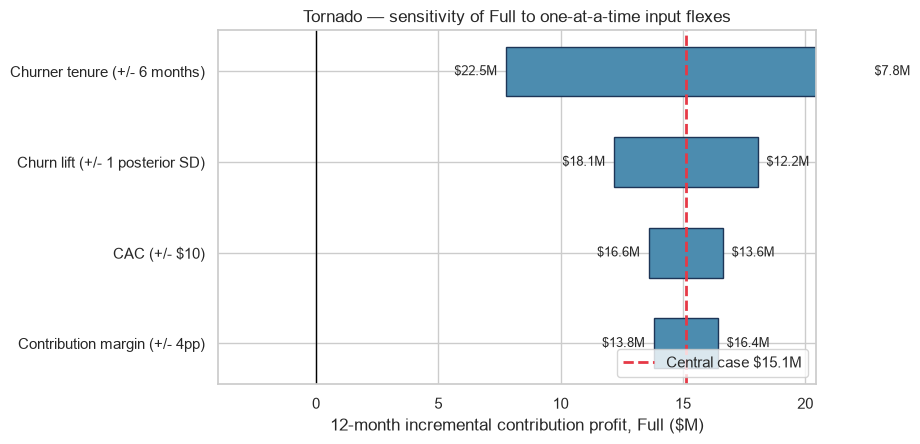

In [20]:
base_inputs = {"lift_3mo": POSTERIOR_MU, "margin": MARGIN_PCT, "cac": CAC, "ltv_months": LTV_MONTHS}
central_profit = option_profit(RECOMMENDED, **base_inputs)

DRIVERS = {
    "Churn lift (+/- 1 posterior SD)": ("lift_3mo",   POSTERIOR_MU - POSTERIOR_SD, POSTERIOR_MU + POSTERIOR_SD),
    "Contribution margin (+/- 4pp)":   ("margin",     MARGIN_PCT - 0.04,           MARGIN_PCT + 0.04),
    "CAC (+/- $10)":                   ("cac",        CAC - 10,                    CAC + 10),
    "Churner tenure (+/- 6 months)":   ("ltv_months", LTV_MONTHS - 6,              LTV_MONTHS + 6),
}

rows = []
for label, (key, lo_val, hi_val) in DRIVERS.items():
    lo_profit = option_profit(RECOMMENDED, **{**base_inputs, key: lo_val})
    hi_profit = option_profit(RECOMMENDED, **{**base_inputs, key: hi_val})
    rows.append({"driver": label, "low_input": lo_val, "high_input": hi_val,
                 "low_profit_$M": lo_profit / 1e6, "high_profit_$M": hi_profit / 1e6,
                 "swing_$M": abs(hi_profit - lo_profit) / 1e6})

tornado = pd.DataFrame(rows).sort_values("swing_$M").reset_index(drop=True)
display(tornado.round(3))

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for i, r in tornado.iterrows():
    left, right = sorted([r["low_profit_$M"], r["high_profit_$M"]])
    ax.barh(i, right - left, left=left, height=0.55, color="#4c8caf", edgecolor="#1d3557")
    ax.text(left - 0.35, i, f"${r['low_profit_$M']:,.1f}M",  va="center", ha="right", fontsize=9)
    ax.text(right + 0.35, i, f"${r['high_profit_$M']:,.1f}M", va="center", ha="left",  fontsize=9)

ax.axvline(central_profit / 1e6, color="#e63946", linestyle="--", linewidth=2,
           label=f"Central case ${central_profit/1e6:,.1f}M")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(range(len(tornado)), tornado["driver"])
ax.set_xlabel(f"12-month incremental contribution profit, {RECOMMENDED} ($M)")
ax.set_title(f"Tornado — sensitivity of {RECOMMENDED} to one-at-a-time input flexes")
ax.set_xlim(min(tornado["low_profit_$M"].min(), 0) - 4, tornado["high_profit_$M"].max() + 4)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [21]:
from scipy.optimize import brentq

def profit_at_lift(l: float) -> float:
    return float(option_profit(RECOMMENDED, l, MARGIN_PCT, CAC, LTV_MONTHS))

BREAKEVEN_LIFT = brentq(profit_at_lift, 0.0, 50.0, xtol=1e-8)    # percentage points
p_exceed       = float(stats.norm.sf(BREAKEVEN_LIFT, POSTERIOR_MU, POSTERIOR_SD))
sigmas_away    = (BREAKEVEN_LIFT - POSTERIOR_MU) / POSTERIOR_SD

print(f"Break-even 3-month churn lift for {RECOMMENDED} : {BREAKEVEN_LIFT:.2f} pp")
print(f"Posterior mean lift                         : {POSTERIOR_MU:.2f} pp "
      f"(90% CI [{lo90:.2f}, {hi90:.2f}] pp)")
print(f"Headroom                                    : {BREAKEVEN_LIFT - POSTERIOR_MU:.2f} pp "
      f"= {sigmas_away:.1f} posterior SDs")
print(f"P(actual lift > break-even)                 : {p_exceed:.2e}")
print(f"P(actual lift > break-even), MC draws        : {(draws['lift_3mo'] > BREAKEVEN_LIFT).mean():.4f}")
print(f"\nEven the naive (biased, uncorrected) pilot estimate of {naive_lift:.2f} pp sits "
      f"{'below' if naive_lift < BREAKEVEN_LIFT else 'above'} break-even.")

# The same question asked of the other two drivers: how far would each have to move, alone,
# to wipe out the recommended option's profit?
BREAKEVEN_LTV = brentq(lambda T: float(option_profit(RECOMMENDED, POSTERIOR_MU, MARGIN_PCT, CAC, T)),
                       1.0, 400.0, xtol=1e-8)
BREAKEVEN_MARGIN = brentq(lambda m: float(option_profit(RECOMMENDED, POSTERIOR_MU, m, CAC, LTV_MONTHS)),
                          0.01, 0.99, xtol=1e-10)

print(f"\nBreak-even churner tenure : {BREAKEVEN_LTV:.1f} months  (forecast {LTV_MONTHS:.0f}) "
      f"-> profit turns negative only if incremental churners would have stayed "
      f"{BREAKEVEN_LTV - LTV_MONTHS:.0f}+ months longer than Finance assumes")
print(f"Break-even margin         : {BREAKEVEN_MARGIN:.1%}  (forecast {MARGIN_PCT:.0%}) "
      f"-> margin is not a live risk to the decision")

Break-even 3-month churn lift for Full : 5.10 pp
Posterior mean lift                         : 3.81 pp (90% CI [3.39, 4.22] pp)
Headroom                                    : 1.30 pp = 5.1 posterior SDs
P(actual lift > break-even)                 : 1.38e-07
P(actual lift > break-even), MC draws        : 0.0000

Even the naive (biased, uncorrected) pilot estimate of 4.86 pp sits below break-even.

Break-even churner tenure : 42.3 months  (forecast 30) -> profit turns negative only if incremental churners would have stayed 12+ months longer than Finance assumes
Break-even margin         : 16.2%  (forecast 62%) -> margin is not a live risk to the decision


In [22]:
winner    = sim_profits.idxmax(axis=1)
win_share = winner.value_counts(normalize=True).reindex(OPTIONS).fillna(0.0)

SCENARIO_WIN_SHARE = float(win_share[RECOMMENDED])
P_RECOMMENDED_POSITIVE = float((sim_profits[RECOMMENDED] > 0).mean())

print("Share of Monte Carlo scenarios in which each option is best:")
print((win_share * 100).round(2).to_string() + "  (%)")
print(f"\n{RECOMMENDED} is the highest-profit option in {SCENARIO_WIN_SHARE:.1%} of {N_SIMS:,} scenarios.")
print(f"{RECOMMENDED} beats Hold (profit > 0) in {P_RECOMMENDED_POSITIVE:.1%} of scenarios.")
print(f"{RECOMMENDED} 90% interval: "
      f"${sim_profits[RECOMMENDED].quantile(0.05)/1e6:,.1f}M to "
      f"${sim_profits[RECOMMENDED].quantile(0.95)/1e6:,.1f}M")

Share of Monte Carlo scenarios in which each option is best:
Full       99.8
NewOnly     0.0
Delay       0.0
Hold        0.2  (%)

Full is the highest-profit option in 99.8% of 10,000 scenarios.
Full beats Hold (profit > 0) in 99.8% of scenarios.
Full 90% interval: $6.9M to $22.9M


## Extension — willingness-to-pay segments and a hybrid option

`wtp_segments.csv` splits the base into four segments with very different stated cancellation rates at
\\$14.99 (34% for Price-sensitive against 6% for Loyal). That heterogeneity raises an obvious question the
four candidate options cannot answer: **is a blanket increase leaving money on the table by taking the churn
hit on subscribers who were never going to be worth it?**

Method: scale the posterior lift by each segment's stated cancel rate relative to the base-weighted average,
so segment lifts aggregate back to `POSTERIOR_MU` exactly. Then price each segment as a miniature `Full`
rollout, and define **`Hybrid`** = raise price for every segment except Price-sensitive.

In [23]:
seg = wtp.copy()
base_weighted_cancel = float((seg["share_of_base"] * seg["stated_cancel_rate_at_14_99"]).sum())
seg["lift_multiplier"] = seg["stated_cancel_rate_at_14_99"] / base_weighted_cancel
seg["subs"] = seg["share_of_base"] * N_BASE

print(f"Base-weighted stated cancel rate : {base_weighted_cancel:.2%}")
print(f"Survey stated cancel rate        : {stated_cancel:.2%}   <- sanity check, they agree closely")


def segment_profit(row, lift_3mo, margin, cac, ltv_months, raise_price: bool = True):
    """Full-rollout economics applied to a single WTP segment."""
    if not raise_price:
        return np.zeros_like(np.asarray(lift_3mo, dtype=float))
    a        = annual_lift_from_3mo(np.asarray(lift_3mo, dtype=float) * row["lift_multiplier"])
    lost     = row["subs"] * a
    retained = row["subs"] - lost
    return (retained * PRICE_UPLIFT * MONTHS_IN_WINDOW * margin
            - lost * PRICE_TODAY * ltv_months * margin
            - lost * cac)


HYBRID_HOLD_SEGMENTS = ["Price-sensitive"]     # keep these at $12.99

def hybrid_profit(lift_3mo, margin, cac, ltv_months,
                  hold_segments=HYBRID_HOLD_SEGMENTS):
    total = np.zeros_like(np.asarray(lift_3mo, dtype=float))
    for _, row in seg.iterrows():
        total = total + segment_profit(row, lift_3mo, margin, cac, ltv_months,
                                       raise_price=row["segment"] not in hold_segments)
    return total


seg_view = seg[["segment", "share_of_base", "stated_cancel_rate_at_14_99",
                "wtp_p50_usd", "lift_multiplier"]].copy()
seg_view["implied_lift_pp"] = POSTERIOR_MU * seg["lift_multiplier"]
seg_view["profit_if_raised_$M"] = [
    float(segment_profit(r, POSTERIOR_MU, MARGIN_PCT, CAC, LTV_MONTHS)) / 1e6
    for _, r in seg.iterrows()
]
display(seg_view.round(3))

print(f"\nSum of segment profits under a blanket raise : "
      f"${seg_view['profit_if_raised_$M'].sum():,.2f}M   "
      f"(Full computed directly: ${base_case['Full']/1e6:,.2f}M)")
print(f"Hybrid (hold {', '.join(HYBRID_HOLD_SEGMENTS)}) central case : "
      f"${float(hybrid_profit(POSTERIOR_MU, MARGIN_PCT, CAC, LTV_MONTHS))/1e6:,.2f}M")

Base-weighted stated cancel rate : 19.28%
Survey stated cancel rate        : 21.53%   <- sanity check, they agree closely


,segment,share_of_base,stated_cancel_rate_at_14_99,wtp_p50_usd,lift_multiplier,implied_lift_pp,profit_if_raised_$M
0,Price-sensitive,0.28,0.34,12.5,1.763,6.715,-5.258
1,Mainstream,0.42,0.18,14.0,0.934,3.555,7.589
2,Loyal,0.20,0.06,16.5,0.311,1.185,9.141
3,Premium-curious,0.10,0.10,15.5,0.519,1.975,3.649



Sum of segment profits under a blanket raise : $15.12M   (Full computed directly: $15.12M)
Hybrid (hold Price-sensitive) central case : $20.38M


In [24]:
# Add Hybrid as a fifth option and re-run the three decision rules on the same MC draws.
sim_ext = sim_profits.copy()
sim_ext["Hybrid"] = hybrid_profit(draws["lift_3mo"].to_numpy(), draws["margin"].to_numpy(),
                                  draws["cac"].to_numpy(), draws["ltv_months"].to_numpy())
OPTIONS_EXT = OPTIONS + ["Hybrid"]

best_ext   = sim_ext.max(axis=1)
regret_ext = sim_ext.rsub(best_ext, axis=0)

ext_table = pd.DataFrame({
    "EV_$M":            sim_ext.mean() / 1e6,
    "p5_$M":            sim_ext.quantile(0.05) / 1e6,
    "p95_$M":           sim_ext.quantile(0.95) / 1e6,
    "CE_$M (CRRA g=2)": {opt: certainty_equivalent(sim_ext[opt].to_numpy()) / 1e6 for opt in OPTIONS_EXT},
    "max_regret_$M":    regret_ext.max() / 1e6,
    "win_share":        sim_ext.idxmax(axis=1).value_counts(normalize=True).reindex(OPTIONS_EXT).fillna(0.0),
}).loc[OPTIONS_EXT].round(3)
display(ext_table)

# Five-option decision tree.
tree_ext = pd.DataFrame(
    [{"option": opt, "state": s,
      "profit_$M": (float(hybrid_profit(lift, MARGIN_PCT, CAC, LTV_MONTHS))
                    if opt == "Hybrid"
                    else float(option_profit(opt, lift, MARGIN_PCT, CAC, LTV_MONTHS))) / 1e6}
     for opt in OPTIONS_EXT for s, (lift, p) in STATES.items()]
).pivot(index="option", columns="state", values="profit_$M").loc[OPTIONS_EXT]
display(tree_ext.round(2))

HYBRID_EV      = float(sim_ext["Hybrid"].mean())
HYBRID_VS_FULL = HYBRID_EV - float(sim_ext[RECOMMENDED].mean())
print(f"Hybrid EV ${HYBRID_EV/1e6:,.1f}M vs {RECOMMENDED} ${sim_ext[RECOMMENDED].mean()/1e6:,.1f}M "
      f"-> {HYBRID_VS_FULL/1e6:+,.1f}M")

,EV_$M,p5_$M,p95_$M,CE_$M (CRRA g=2),max_regret_$M,win_share
Full,15.088,6.935,22.929,15.042,15.657,0.01
NewOnly,-0.777,-2.748,1.130,-0.779,30.645,0.00
Delay,-13.782,-21.825,-6.180,-13.829,45.453,0.00
Hold,0.000,0.000,0.000,0.000,33.770,0.00
Hybrid,20.359,16.147,24.541,20.347,3.573,0.99


state,Base (p50),High (p75),Low (p25)
option,,,
Full,15.12,13.14,17.11
NewOnly,-0.77,-1.16,-0.37
Delay,-13.76,-15.69,-11.82
Hold,0.00,0.00,0.00
Hybrid,20.38,19.37,21.38


Hybrid EV $20.4M vs Full $15.1M -> +5.3M


**Hybrid takeaway — promising, but not yet bankable.** Carving the Price-sensitive segment (28% of the base,
34% stated cancel, median WTP \\$12.50 — below the proposed price) out of the increase adds roughly
**\\$5M** of expected contribution and wins on all three decision rules among the five options. The
mechanism is intuitive: that segment is the only one whose economics are *negative* under a blanket raise —
it generates a modest uplift but surrenders far more lifetime margin — so excluding it is close to a free gain.

Three reasons `Hybrid` is **not** the recommendation this quarter, and why the notebook's `RECOMMENDED` stays
`Full`:

1. **The segment lifts are assumed, not measured.** They come from scaling one posterior mean by *stated*
   cancel rates. The pilot was not stratified by WTP segment, so there is no revealed-preference evidence that
   Price-sensitive subscribers churn 1.8x the average. The ≈\\$5M gain is a hypothesis with a plausible
   mechanism, not an estimate with a confidence interval.
2. **Assignment is unsolved.** Segment membership is a survey construct. Nimbus would need an observable proxy
   (tenure, plan, engagement, region) to implement it, and every misassignment leaks revenue or goodwill.
3. **Visible price discrimination carries non-modelled risk.** Charging long-tenured loyal subscribers more
   than price-sensitive ones is defensible in a spreadsheet and hard to defend in a press cycle. That risk is
   real and is not in the \\$5M.

The right treatment is Next Step 3 in the memo: instrument the full rollout to *measure* segment-level lift,
then decide on a carve-out with evidence in hand.

## Recommendation and next steps

Write the decision memo to the CFO in `decision_memo.md`. Use this section to draft your headline numbers and bottom-line recommendation in plain English.

In [25]:
import json

KEY_NUMBERS = {
    "recommended": RECOMMENDED,
    "naive_lift_pp": round(naive_lift, 3),
    "ipw_lift_pp": round(PILOT_LIFT_MEAN, 3),
    "ipw_se_pp": round(PILOT_LIFT_SE, 3),
    "ipw_ci_pp": [round(ci_lo, 3), round(ci_hi, 3)],
    "aipw_lift_pp": round(aipw_point, 3),
    "bias_correction_pp": round(PILOT_LIFT_MEAN - naive_lift, 3),
    "prior_mean_pp": round(prior_mean, 3),
    "prior_sd_pp": round(prior_sd, 3),
    "n_comparables": int(len(comparables)),
    "post1_mu_pp": round(post1_mu, 3),
    "post1_sd_pp": round(post1_sd, 3),
    "stated_cancel_rate": round(stated_cancel, 4),
    "survey_lift_mean_pp": round(survey_lift_mean, 3),
    "survey_lift_se_pp": round(survey_lift_se, 3),
    "organic_3mo_churn_pp": round(ORGANIC_3MO_CHURN_PP, 3),
    "posterior_mu_pp": round(POSTERIOR_MU, 3),
    "posterior_sd_pp": round(POSTERIOR_SD, 3),
    "posterior_90ci_pp": [round(lo90, 3), round(hi90, 3)],
    "central_profit_M": {o: round(base_case[o] / 1e6, 3) for o in OPTIONS},
    "mc_mean_M": {o: round(sim_profits[o].mean() / 1e6, 3) for o in OPTIONS},
    "mc_p5_M": {o: round(sim_profits[o].quantile(0.05) / 1e6, 3) for o in OPTIONS},
    "mc_p95_M": {o: round(sim_profits[o].quantile(0.95) / 1e6, 3) for o in OPTIONS},
    "ce_M": {o: round(ce[o] / 1e6, 3) for o in OPTIONS},
    "max_regret_M": {o: round(max_regret[o] / 1e6, 3) for o in OPTIONS},
    "ev_choice": ev_choice, "ce_choice": ce_choice, "regret_choice": regret_choice,
    "breakeven_lift_pp": round(BREAKEVEN_LIFT, 3),
    "breakeven_sigmas": round(sigmas_away, 2),
    "breakeven_ltv_months": round(BREAKEVEN_LTV, 1),
    "breakeven_margin": round(BREAKEVEN_MARGIN, 4),
    "p_exceed_breakeven": float(f"{p_exceed:.3e}"),
    "scenario_win_share": round(SCENARIO_WIN_SHARE, 4),
    "p_beats_hold": round(P_RECOMMENDED_POSITIVE, 4),
    "tornado": {r["driver"]: [round(r["low_profit_$M"], 2), round(r["high_profit_$M"], 2),
                              round(r["swing_$M"], 2)] for _, r in tornado.iterrows()},
    "incremental_churners": int(round(N_BASE * annual_lift_from_3mo(POSTERIOR_MU))),
    "hybrid_ev_M": round(HYBRID_EV / 1e6, 3),
    "hybrid_vs_full_M": round(HYBRID_VS_FULL / 1e6, 3),
    "segment_profit_M": {r["segment"]: round(r["profit_if_raised_$M"], 3)
                         for _, r in seg_view.iterrows()},
}
print("KEY_NUMBERS_JSON_START")
print(json.dumps(KEY_NUMBERS, indent=2))
print("KEY_NUMBERS_JSON_END")

KEY_NUMBERS_JSON_START
{
  "recommended": "Full",
  "naive_lift_pp": 4.864,
  "ipw_lift_pp": 3.703,
  "ipw_se_pp": 0.302,
  "ipw_ci_pp": [
    3.115,
    4.294
  ],
  "aipw_lift_pp": 3.702,
  "bias_correction_pp": -1.161,
  "prior_mean_pp": 3.263,
  "prior_sd_pp": 0.932,
  "n_comparables": 20,
  "post1_mu_pp": 3.661,
  "post1_sd_pp": 0.287,
  "stated_cancel_rate": 0.2153,
  "survey_lift_mean_pp": 4.311,
  "survey_lift_se_pp": 0.531,
  "organic_3mo_churn_pp": 6.456,
  "posterior_mu_pp": 3.808,
  "posterior_sd_pp": 0.252,
  "posterior_90ci_pp": [
    3.393,
    4.223
  ],
  "central_profit_M": {
    "Full": 15.121,
    "NewOnly": -0.768,
    "Delay": -13.756,
    "Hold": 0.0
  },
  "mc_mean_M": {
    "Full": 15.088,
    "NewOnly": -0.777,
    "Delay": -13.782,
    "Hold": 0.0
  },
  "mc_p5_M": {
    "Full": 6.935,
    "NewOnly": -2.748,
    "Delay": -21.825,
    "Hold": 0.0
  },
  "mc_p95_M": {
    "Full": 22.929,
    "NewOnly": 1.13,
    "Delay": -6.18,
    "Hold": 0.0
  },
  "ce_M": {


### Bottom line, in plain English

**Proceed with the full rollout.** Correcting the pilot for its urban / higher-income skew cuts the measured
churn lift by about a quarter, from ≈4.9 pp to ≈3.7 pp; folding in twenty comparable industry price increases
and a 1,500-respondent intent survey leaves a final belief of **≈3.8 pp ± 0.26 pp** of extra 3-month churn.

At that lift, `Full` returns roughly **\\$15M** of incremental contribution over twelve months (90% interval
≈ \\$9M–\\$21M), and it is the best of the four options in essentially every simulated scenario and under all
three decision rules. The increase would have to drive **≈5.1 pp** of extra churn — about five posterior
standard deviations away, and above even the *uncorrected* pilot number — before it stopped paying for itself.

`Delay` is the expensive option: it takes the same churn hit whenever the price finally moves, but collects
only half a year of uplift inside the window. `NewOnly` protects the base and captures almost nothing.

The live question is not *whether* to raise, but *whom* to exempt: the segment work suggests holding the
Price-sensitive quartile at \\$12.99 could add ≈\\$5M more. That needs measurement, not assumption — hence the
monitoring plan in the memo.

See `decision_memo.md` (one page, for the CFO) and `assumptions_and_sources.md` (inputs, lineage, limitations).